# 2026 Australian Grand Prix — Race Debrief

**Date:** March 8, 2026 \
**Circuit:** Melbourne Grand Prix Circuit \
**Winner:** George Russell (Mercedes) 

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished l

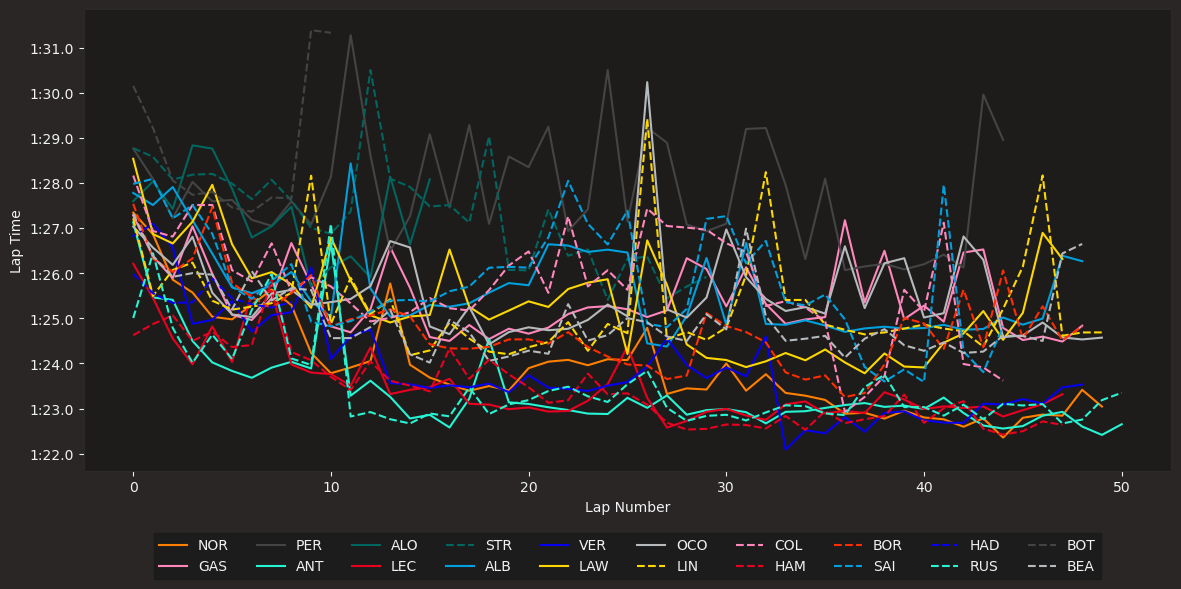

In [1]:
import fastf1 as ff1
import pandas as pd
from fastf1 import plotting
from matplotlib import pyplot as plt

ff1.Cache.enable_cache("/Users/hai/fastf1_cache/")

session = ff1.get_session(2026, 1, "R")
session.load()

laps = session.laps
laps_df = pd.DataFrame(laps)

drivers = laps_df['Driver'].unique()

ff1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

fig, ax = plt.subplots(figsize=(12, 6))
for driver in drivers:
    laps = session.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(identifier=driver,
                                      style=['color', 'linestyle'],
                                      session=session)
    ax.plot(laps['LapTime'], **style, label=driver)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=10)

plt.tight_layout()
plt.show()